Practice Project – Customer Churn Prediction System
Requirements
1. Preprocess dataset
2. Train:
- [Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [Decision Tree](https://scikit-learn.org/stable/modules/tree.html)
- Random Forest :[1.11. Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html)
3. Compare models
4. Evaluate:

For classification models:
- a. [Confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
- b. [ROC curve](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)
- c. Precision/Recall tradeoff :[Precision-Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#precision-recall)

For regression models:
- a. MAE,
- b. MAPE,
- c. MSE
5. Feature importance analysis

## Biblioteci folostie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Preprocess dataset
### Importarea datelor 

In [3]:
data_for_training = pd.read_csv("customer_churn_dataset\\customer_churn_dataset-training-master.csv")

data_for_testing = pd.read_csv("customer_churn_dataset\\customer_churn_dataset-testing-master.csv")

In [4]:
data_for_training

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [5]:
data_for_testing

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [6]:
data_for_training.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

### Verificare duplicate 

In [7]:
data_for_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [8]:
data_for_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [9]:
data_for_training.duplicated().value_counts()

False    440833
Name: count, dtype: int64

In [10]:
data_for_testing.duplicated().value_counts()

False    64374
Name: count, dtype: int64

In [11]:
data_for_training.duplicated().sum()

np.int64(0)

In [12]:
data_for_training.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [13]:
data_for_training.dropna(inplace=True)

In [14]:
data_for_training.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [15]:
data_for_training.drop(columns=["CustomerID"],inplace=True)
data_for_testing.drop(columns=["CustomerID"],inplace=True)

In [16]:
data_for_training["Gender"].apply(lambda x:1 if x=="Male" else 0)

0         0
1         0
2         0
3         1
4         1
         ..
440828    1
440829    0
440830    1
440831    1
440832    1
Name: Gender, Length: 440832, dtype: int64

In [17]:
data_for_training.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [18]:
data_for_training["Gender"]=data_for_training["Gender"].apply(lambda x:1 if x=="Male" else 0)

data_for_testing["Gender"]=data_for_testing["Gender"].apply(lambda x:1 if x=="Male" else 0)

In [19]:
data_for_training.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [20]:
data_for_training["Subscription Type"].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [21]:
data_for_training["Contract Length"].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [22]:
#* Annuall  =2 ;Quarterly = 1 ; Monthly = 0
data_for_training["Contract Length"]=data_for_training["Contract Length"].apply(lambda x:2 if x=="Annual" else(1 if x=="Quarterly" else 0))
data_for_testing["Contract Length"]=data_for_testing["Contract Length"].apply(lambda x:2 if x=="Annual" else(1 if x=="Quarterly" else 0))

In [23]:
data_for_training.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  int64  
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  int64  
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), int64(2), str(1)
memory usage: 40.4 MB


In [24]:
data_for_testing

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,Basic,0,598,9,1
1,41,0,28,28,7,13,Standard,0,584,20,0
2,47,1,27,10,2,29,Premium,2,757,21,0
3,35,1,9,12,5,17,Premium,1,232,18,0
4,53,0,58,24,9,2,Standard,2,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45,0,33,12,6,21,Basic,1,947,14,1
64370,37,1,6,1,5,22,Standard,2,923,9,1
64371,25,1,39,14,8,30,Premium,0,327,20,1
64372,50,0,18,19,7,22,Standard,0,540,13,1


In [25]:
#Premium 2 Standard 1 si basic 0
data_for_training["Subscription Type"]=data_for_training["Subscription Type"].apply(lambda x:2 if x=="Premium" else(1 if x=="Standard" else 0 ))
data_for_testing["Subscription Type"]=data_for_testing["Subscription Type"].apply(lambda x:2 if x=="Premium" else(1 if x=="Standard" else 0 ))

In [26]:
data_for_testing["Subscription Type"]

0        0
1        1
2        2
3        2
4        1
        ..
64369    0
64370    1
64371    2
64372    1
64373    1
Name: Subscription Type, Length: 64374, dtype: int64

In [27]:
data_for_training["Subscription Type"].value_counts()

Subscription Type
1    149128
2    148678
0    143026
Name: count, dtype: int64

In [28]:
data_for_training.reindex()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0,0.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0,0.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0,0.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0,0.0


In [29]:
data_for_training.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

In [30]:
data_for_training[["Age",'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction']]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


In [31]:
#train
X_train =data_for_training[["Age", "Gender", 'Tenure', 'Usage Frequency', 'Support Calls','Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend','Last Interaction']]
y_train = data_for_training['Churn']

#test
X_test =data_for_testing[['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls','Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend','Last Interaction']]
y_test = data_for_testing['Churn']

In [32]:
X_train

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


In [33]:
y_train

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
440828    0.0
440829    0.0
440830    0.0
440831    0.0
440832    0.0
Name: Churn, Length: 440832, dtype: float64

In [34]:
X_train

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


### Standardizing the features

In [35]:
scaler_z = StandardScaler()
X_standardized_train = X_train.copy()
X_standardized_test = X_test.copy()

# X_standardized_train[["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]]=scaler_z.fit_transform(X_train[["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]])
features_to_standardized =["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]

for features in features_to_standardized:
    X_standardized_train[features] = scaler_z.fit_transform(X_train[[features]])

for features in features_to_standardized:
    X_standardized_test[features] = scaler_z.fit_transform(X_test[[features]])

X_standardized_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,-0.753326,0,0.448760,-0.210511,0.454549,0.609620,1,2,1.247427,0.293052
1,2.059646,0,1.028278,-1.724562,2.083100,-0.601319,0,0,-0.309865,-0.986584
2,1.255940,0,-1.000036,-1.375166,0.780259,0.609620,0,1,-1.854698,-1.335575
3,1.497051,1,0.390808,0.604748,1.105969,-0.722413,1,0,-0.978462,1.689018
4,-1.315921,1,0.043097,0.488282,0.454549,-0.601319,0,0,-0.060698,0.642043


In [36]:
X_standardized_test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,-1.434202,0,-0.409100,-0.122526,-0.449807,1.114538,0,0,0.218408,-0.752324
1,-0.069730,0,-0.233642,1.465424,0.513590,-0.467000,1,0,0.164742,0.521065
2,0.361155,1,-0.292128,-0.576225,-1.092072,1.340472,2,2,0.827900,0.636827
3,-0.500616,1,-1.344876,-0.349375,-0.128674,-0.015132,2,1,-1.184575,0.289540
4,0.792041,0,1.520939,1.011724,1.155855,-1.709637,1,2,-0.030756,0.289540


In [37]:
plt.style.use('petroff8')

<Axes: >

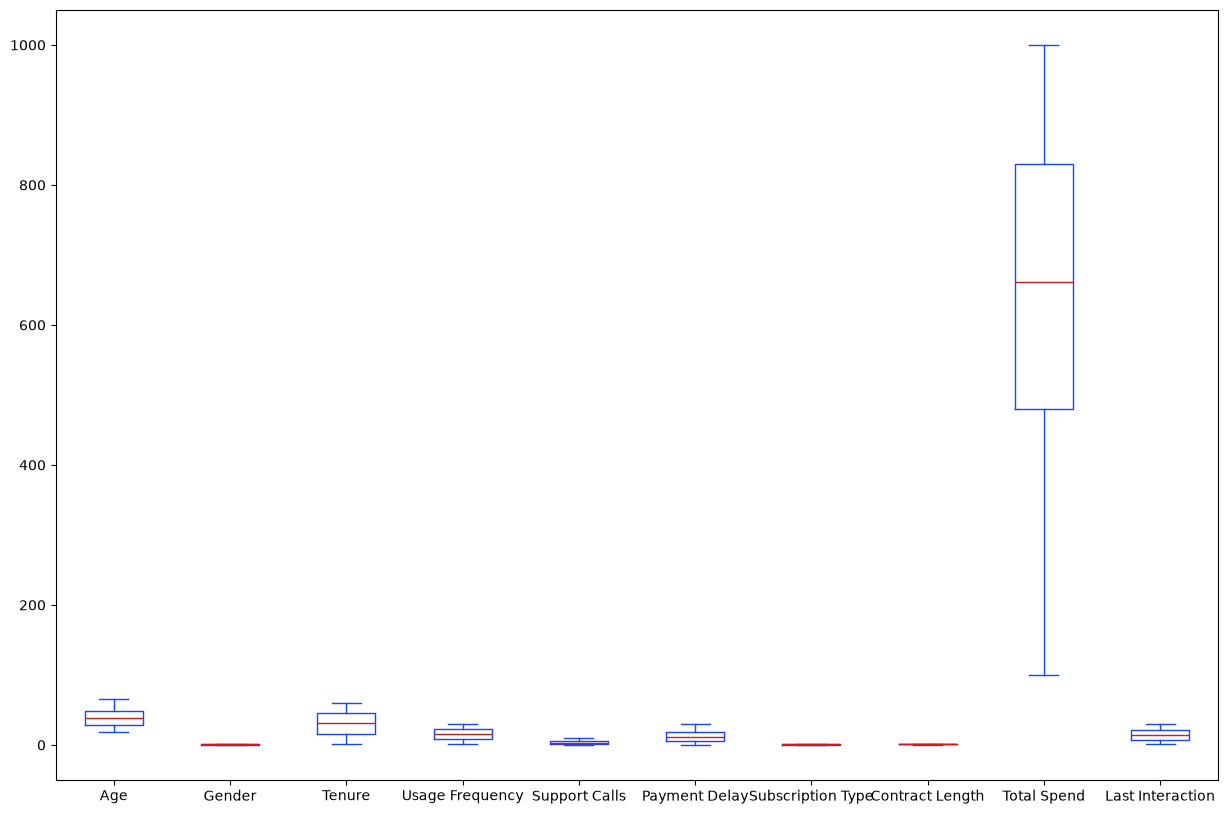

In [38]:

X_train.plot.box(figsize=(15,10))


<Axes: >

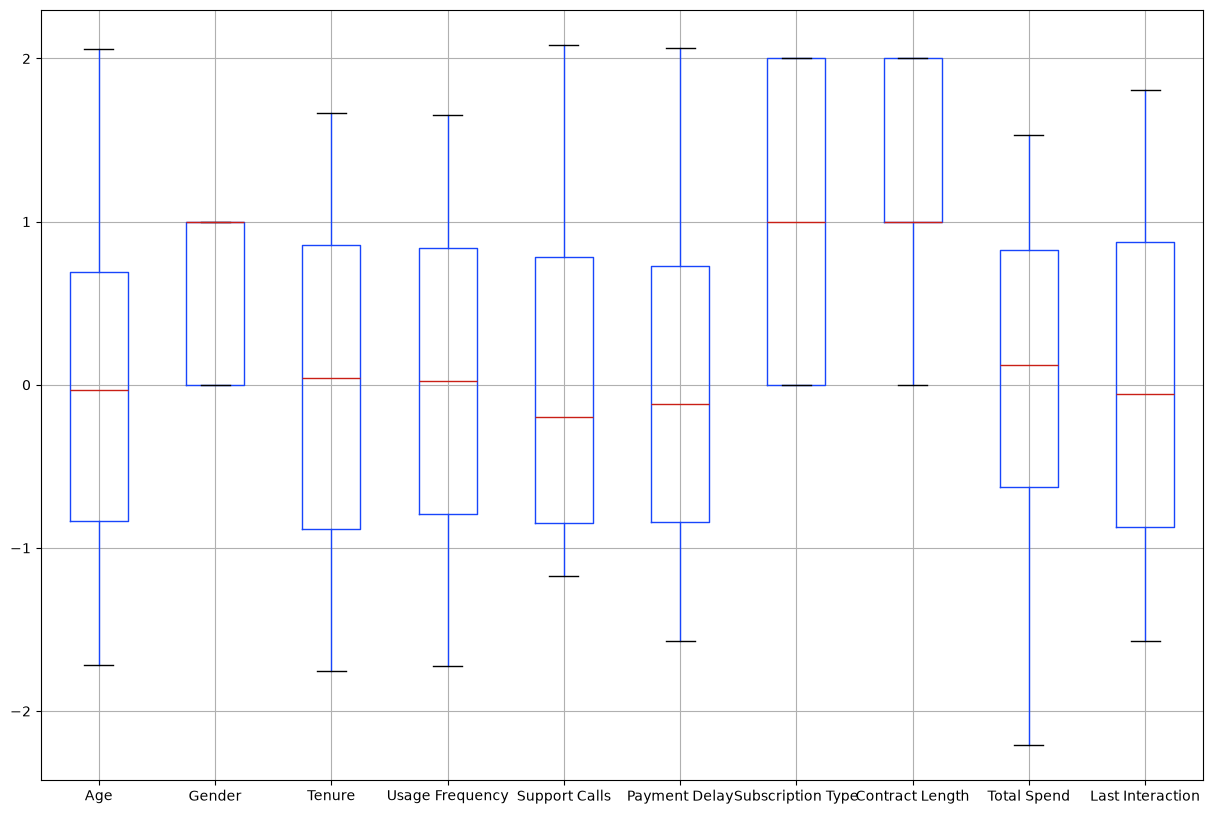

In [39]:
X_standardized_train.boxplot(figsize=(15,10))

In [ ]:
# X_test.plot()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  int64
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  int64
 7   Contract Length    64374 non-null  int64
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
dtypes: int64(10)
memory usage: 4.9 MB


<Axes: >

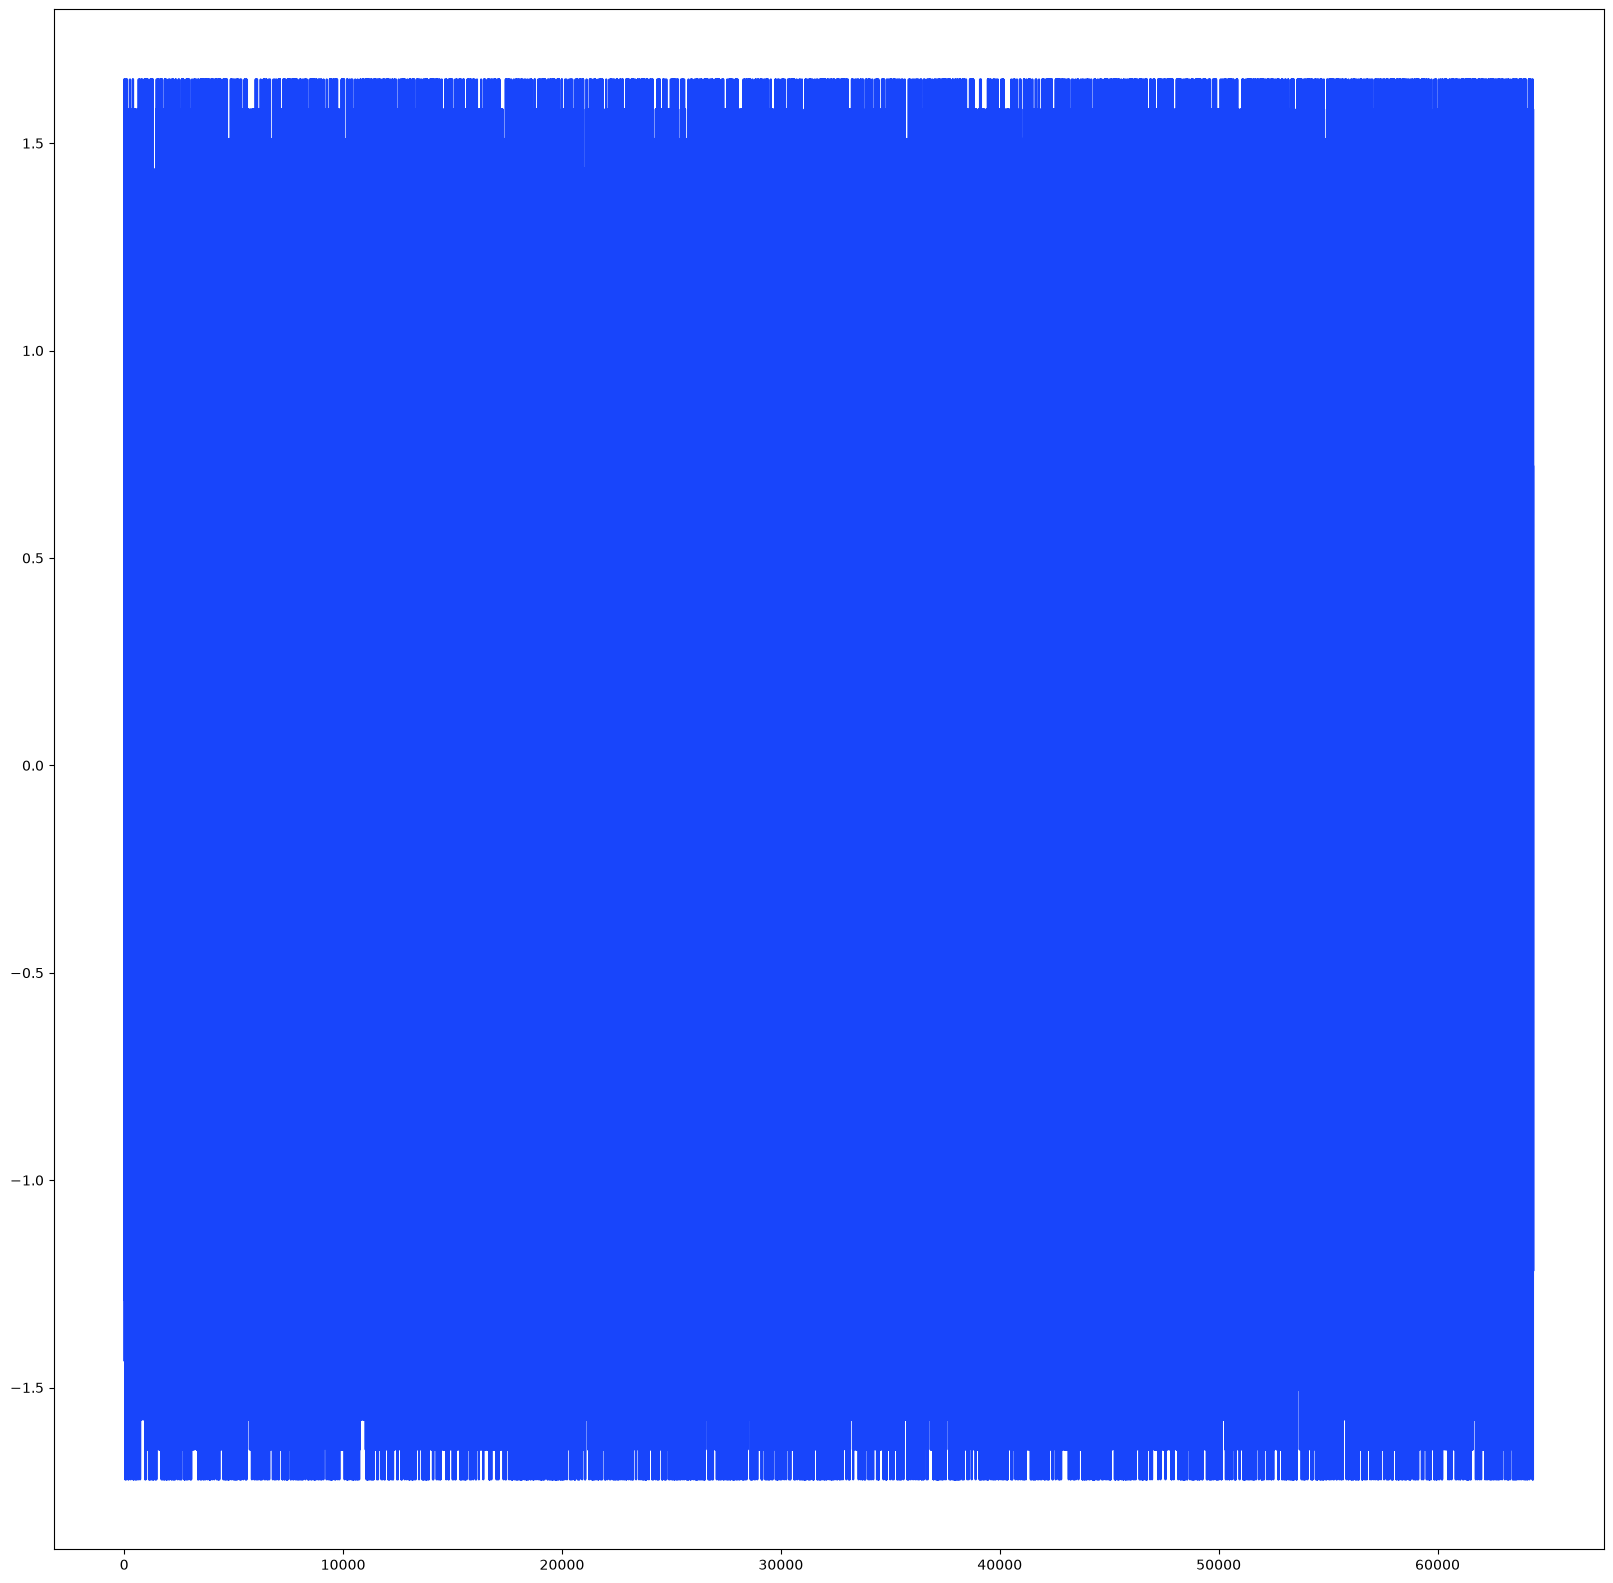

# Bibliografie
- [Customer Churn dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset?select=customer_churn_dataset-training-master.csv) 